In [118]:
import pandas as pd

df = pd.read_csv("/content/Airbnb_Open_Data.csv")

print(df.shape)
print(df.head())

(102599, 26)
        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.972

/tmp/ipykernel_2245/2689421057.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Airbnb_Open_Data.csv")


In [119]:
import pandas as pd

df = pd.read_csv(
    "/content/Airbnb_Open_Data.csv",
    low_memory=False
)

print("Rows and Columns:", df.shape)

Rows and Columns: (102599, 26)


In [120]:
missing_values = df.isnull().sum()

print(missing_values)

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [121]:
import pandas as pd

df = pd.read_csv("/content/Airbnb_Open_Data.csv", low_memory=False)

print(df.shape)

(102599, 26)


In [122]:
# Convert price and service fee from text to numbers

df['price'] = (
    df['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

df['service fee'] = (
    df['service fee']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
)

# Convert to numeric
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['service fee'] = pd.to_numeric(df['service fee'], errors='coerce')

# Numerical columns
numeric_columns = [
    'lat',
    'long',
    'Construction year',
    'price',
    'service fee',
    'minimum nights',
    'number of reviews',
    'reviews per month',
    'review rate number',
    'calculated host listings count',
    'availability 365'
]

# Fill numerical missing values
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_columns = [
    'NAME',
    'host_identity_verified',
    'host name',
    'neighbourhood group',
    'neighbourhood',
    'country',
    'country code',
    'instant_bookable',
    'cancellation_policy'
]

# Fill categorical missing values
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Convert last review to date
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Check missing values
print(df.isnull().sum())

/tmp/ipykernel_2245/3139674531.py:57: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


id                                     0
NAME                                   0
host id                                0
host_identity_verified                 0
host name                              0
neighbourhood group                    0
neighbourhood                          0
lat                                    0
long                                   0
country                                0
country code                           0
instant_bookable                       0
cancellation_policy                    0
room type                              0
Construction year                      0
price                                  0
service fee                            0
minimum nights                         0
number of reviews                      0
last review                        15893
reviews per month                      0
review rate number                     0
calculated host listings count         0
availability 365                       0
house_rules     

In [123]:
# Check for duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 541


In [124]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (102058, 26)


In [125]:
print(df[['price', 'service fee', 'minimum nights',
          'number of reviews', 'review rate number',
          'availability 365']].describe())

               price    service fee  minimum nights  number of reviews  \
count  102058.000000  102058.000000   102058.000000      102058.000000   
mean      625.352300     125.039144        8.106547          27.481158   
std       331.271053      66.237136       30.558319          49.534887   
min        50.000000      10.000000    -1223.000000           0.000000   
25%       341.000000      68.000000        2.000000           1.000000   
50%       624.000000     125.000000        3.000000           7.000000   
75%       912.000000     182.000000        5.000000          30.000000   
max      1200.000000     240.000000     5645.000000        1024.000000   

       review rate number  availability 365  
count       102058.000000     102058.000000  
mean             3.277862        140.846264  
std              1.283174        135.164389  
min              1.000000        -10.000000  
25%              2.000000          3.000000  
50%              3.000000         96.000000  
75%        

In [126]:
# Fix invalid minimum nights
df.loc[df['minimum nights'] < 1, 'minimum nights'] = df['minimum nights'].median()

# Fix extremely high minimum nights
df.loc[df['minimum nights'] > 365, 'minimum nights'] = df['minimum nights'].median()

# Fix invalid availability values
df.loc[df['availability 365'] < 0, 'availability 365'] = 0

# Fix availability values above 365
df.loc[df['availability 365'] > 365, 'availability 365'] = 365

print("Invalid values fixed successfully!")

Invalid values fixed successfully!


In [127]:
print(df[['minimum nights', 'availability 365']].describe())

       minimum nights  availability 365
count   102058.000000     102058.000000
mean         7.824570        140.010425
std         17.030748        133.176052
min          1.000000          0.000000
25%          2.000000          3.000000
50%          3.000000         96.000000
75%          5.000000        268.000000
max        365.000000        365.000000


In [128]:
# Count listings by room type
room_counts = df['room type'].value_counts()

print(room_counts)

room type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64


In [129]:
# Count listings by neighbourhood group
neighbourhood_counts = df['neighbourhood group'].value_counts()

print(neighbourhood_counts)

neighbourhood group
Manhattan        43586
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
brookln              1
manhatan             1
Name: count, dtype: int64


In [130]:
# Calculate average price by neighbourhood group
avg_price_neighbourhood = df.groupby(
    'neighbourhood group'
)['price'].mean().sort_values(ascending=False)

print(avg_price_neighbourhood)

neighbourhood group
Queens           630.201485
Bronx            627.755011
Brooklyn         626.496373
Staten Island    623.990516
Manhattan        622.677305
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


In [131]:
# Correct spelling inconsistencies
df['neighbourhood group'] = df['neighbourhood group'].replace({
    'brookln': 'Brooklyn',
    'manhatan': 'Manhattan'
})

# Recalculate average price
avg_price_neighbourhood = df.groupby(
    'neighbourhood group'
)['price'].mean().sort_values(ascending=False)

print(avg_price_neighbourhood)

neighbourhood group
Queens           630.201485
Bronx            627.755011
Brooklyn         626.495256
Staten Island    623.990516
Manhattan        622.673572
Name: price, dtype: float64


In [132]:
# Calculate average price by room type
avg_price_room = df.groupby('room type')['price'].mean().sort_values(ascending=False)

print(avg_price_room)

room type
Hotel room         666.391304
Shared room        634.788949
Entire home/apt    625.236969
Private room       624.933486
Name: price, dtype: float64


In [133]:
# Calculate average number of reviews by room type
avg_reviews_room = df.groupby('room type')['number of reviews'].mean().sort_values(ascending=False)

print(avg_reviews_room)

room type
Hotel room         84.078261
Private room       27.787976
Entire home/apt    27.389882
Shared room        20.307518
Name: number of reviews, dtype: float64


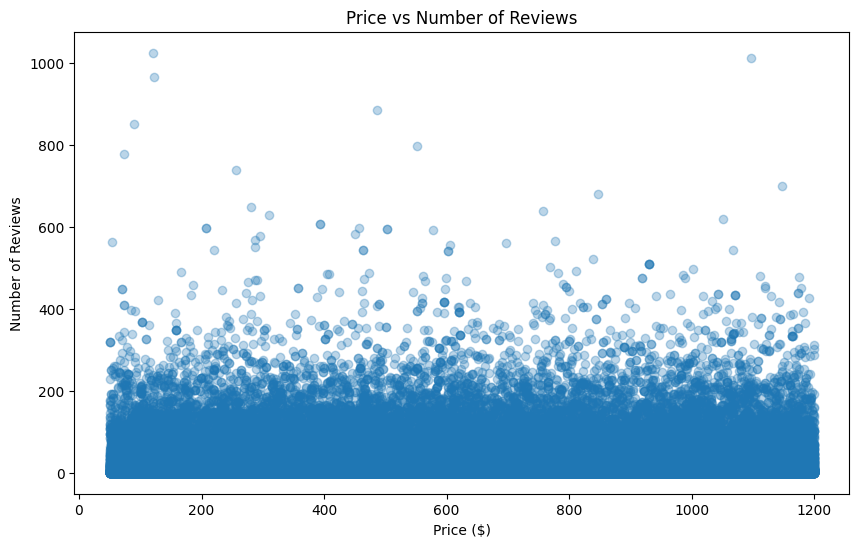

In [134]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['price'],
    df['number of reviews'],
    alpha=0.3
)

plt.xlabel('Price ($)')
plt.ylabel('Number of Reviews')
plt.title('Price vs Number of Reviews')

plt.show()

In [135]:
import matplotlib.pyplot as plt

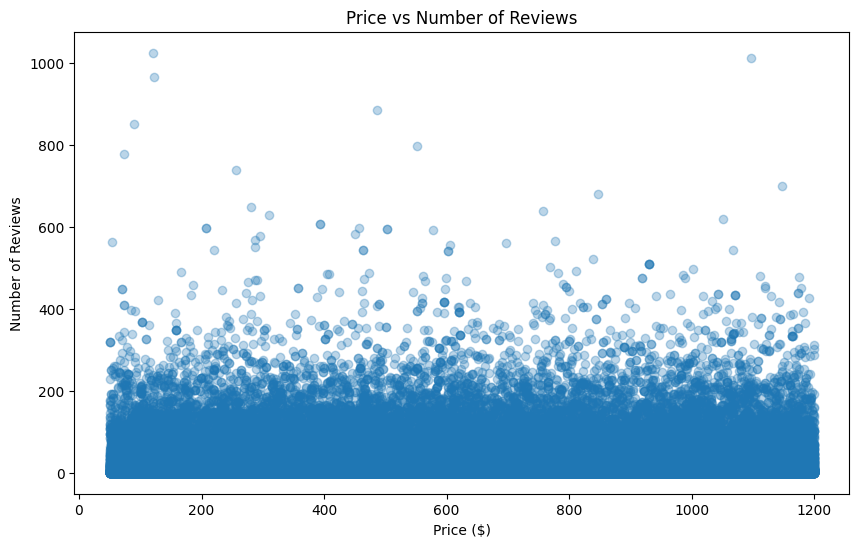

In [136]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['price'],
    df['number of reviews'],
    alpha=0.3
)

plt.xlabel('Price ($)')
plt.ylabel('Number of Reviews')
plt.title('Price vs Number of Reviews')

plt.show()

In [137]:
# Calculate average availability by room type
avg_availability_room = df.groupby(
    'room type'
)['availability 365'].mean().sort_values(ascending=False)

print(avg_availability_room)

room type
Hotel room         219.930435
Shared room        172.181159
Entire home/apt    141.605589
Private room       136.437416
Name: availability 365, dtype: float64


In [138]:
# Top 10 neighbourhoods by number of listings
top_neighbourhoods = df['neighbourhood'].value_counts().head(10)

print(top_neighbourhoods)

neighbourhood
Bedford-Stuyvesant    7914
Williamsburg          7732
Harlem                5441
Bushwick              4956
Hell's Kitchen        3949
Upper West Side       3841
Upper East Side       3656
East Village          3477
Midtown               3357
Crown Heights         3251
Name: count, dtype: int64


In [139]:
# Average price by neighbourhood
avg_price_neighbourhood = df.groupby(
    'neighbourhood'
)['price'].mean().sort_values(ascending=False)

print(avg_price_neighbourhood.head(10))

neighbourhood
New Dorp                  1045.000000
Chelsea, Staten Island    1042.000000
Fort Wadsworth            1024.000000
Little Neck                817.750000
Jamaica Hills              812.904762
Shore Acres                805.142857
Arden Heights              804.888889
Midland Beach              796.176471
Mill Basin                 775.142857
Riverdale                  768.736842
Name: price, dtype: float64


In [140]:
# Calculate estimated minimum-stay booking value
df['estimated_booking_value'] = (
    df['price'] * df['minimum nights']
)

print(df['estimated_booking_value'].describe())

count    102058.000000
mean       4859.019606
std       12156.178643
min          50.000000
25%         728.000000
50%        1540.000000
75%        3453.000000
max      433985.000000
Name: estimated_booking_value, dtype: float64


In [141]:
# Top 10 listings by estimated minimum-stay value
top_booking_value = df[
    ['NAME', 'room type', 'price', 'minimum nights', 'estimated_booking_value']
].sort_values(
    'estimated_booking_value',
    ascending=False
).head(10)

print(top_booking_value)

                                                    NAME        room type  \
5386                 LAST DAY TO BOOK Bedroom on Wall St     Private room   
69626                 Manhattan Sky Crib (1 year sublet)  Entire home/apt   
1450                  Manhattan Sky Crib (1 year sublet)  Entire home/apt   
44430                 Room with sofa bed or air mattress     Private room   
59992    Mia Suite East Village-free Street Parking+wifi  Entire home/apt   
66431     Direct Central Park View from 6th floor Studio  Entire home/apt   
66396  Dreamy 2br Red Hook Escape w/ Roof Deck and a ...  Entire home/apt   
755                  Easy, comfortable studio in Midtown  Entire home/apt   
66188   Bright & Sunny 2-Bed - Bushwick/Bed-Stuy Border!  Entire home/apt   
85722                 Gorgeous Studio in Doorman Luxury!  Entire home/apt   

        price  minimum nights  estimated_booking_value  
5386   1189.0           365.0                 433985.0  
69626  1187.0           365.0         

In [142]:
# Extract year from last review date
df['review_year'] = df['last review'].dt.year

# Count reviews by year
reviews_by_year = df['review_year'].value_counts().sort_index()

print(reviews_by_year)

review_year
2012.0       26
2013.0       80
2014.0      246
2015.0     1850
2016.0     4303
2017.0     6591
2018.0    11403
2019.0    42734
2020.0     2063
2021.0     6556
2022.0    10369
2024.0        1
2025.0        1
2026.0        1
2040.0        1
2058.0        1
Name: count, dtype: int64


In [143]:
# Remove invalid future review years
df.loc[df['review_year'] > 2022, 'review_year'] = pd.NA

# Recalculate review counts
reviews_by_year = df['review_year'].value_counts().sort_index()

print(reviews_by_year)

review_year
2012.0       26
2013.0       80
2014.0      246
2015.0     1850
2016.0     4303
2017.0     6591
2018.0    11403
2019.0    42734
2020.0     2063
2021.0     6556
2022.0    10369
Name: count, dtype: int64


In [144]:
avg_rating_neighbourhood = (
    df.groupby('neighbourhood')['review rate number']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(avg_rating_neighbourhood)

neighbourhood
Glen Oaks          4.500000
Co-op City         4.400000
Gerritsen Beach    4.333333
Huguenot           4.111111
Silver Lake        4.000000
Woodrow            4.000000
West Farms         4.000000
Eltingville        4.000000
Todt Hill          4.000000
Rosebank           3.928571
Name: review rate number, dtype: float64


In [145]:
top_hosts = (
    df.groupby('host id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_hosts)

host id
29531702698    2
65765635975    1
65765267302    1
65764671629    1
65764610014    1
65761971530    1
65761223145    1
65760166410    1
65760031769    1
65759025233    1
dtype: int64


In [146]:
cancellation_analysis = df['cancellation_policy'].value_counts()

print(cancellation_analysis)

cancellation_policy
moderate    34238
strict      33929
flexible    33891
Name: count, dtype: int64


In [147]:
instant_booking = df['instant_bookable'].value_counts()

print(instant_booking)

instant_bookable
False    51291
True     50767
Name: count, dtype: int64


In [148]:
price_by_cancellation = (
    df.groupby('cancellation_policy')['price']
    .mean()
    .sort_values(ascending=False)
)

print(price_by_cancellation)

cancellation_policy
flexible    626.222478
moderate    625.248700
strict      624.587639
Name: price, dtype: float64


In [149]:
median_price_neighbourhood = (
    df.groupby('neighbourhood group')['price']
    .median()
    .sort_values(ascending=False)
)

print(median_price_neighbourhood)

neighbourhood group
Bronx            630.0
Staten Island    627.0
Queens           626.0
Brooklyn         625.0
Manhattan        624.0
Name: price, dtype: float64


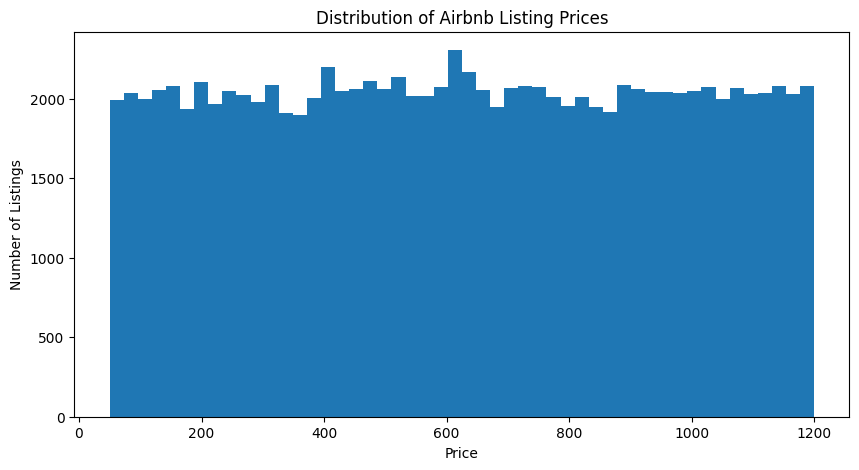

In [150]:
plt.figure(figsize=(10, 5))

plt.hist(df['price'], bins=50)

plt.title('Distribution of Airbnb Listing Prices')
plt.xlabel('Price')
plt.ylabel('Number of Listings')

plt.show()

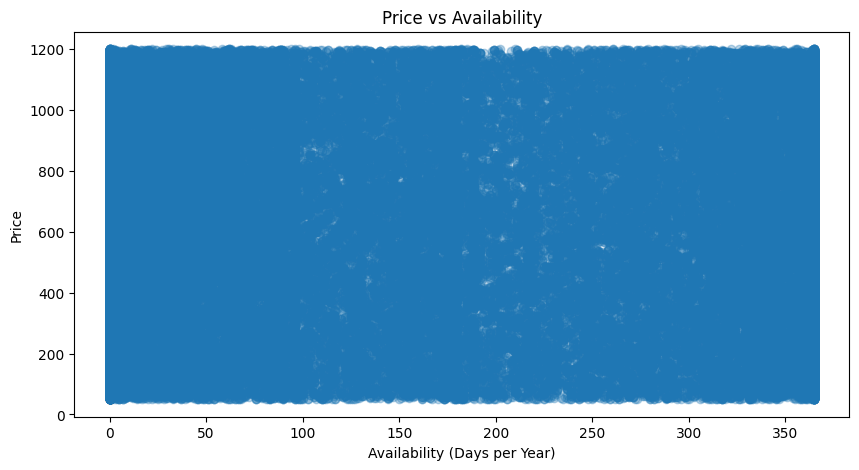

In [151]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df['availability 365'],
    df['price'],
    alpha=0.3
)

plt.title('Price vs Availability')
plt.xlabel('Availability (Days per Year)')
plt.ylabel('Price')

plt.show()

In [152]:
price_room_policy = (
    df.groupby(['room type', 'cancellation_policy'])['price']
    .mean()
    .round(2)
)

print(price_room_policy)

room type        cancellation_policy
Entire home/apt  flexible               628.12
                 moderate               626.32
                 strict                 621.24
Hotel room       flexible               693.61
                 moderate               565.19
                 strict                 741.29
Private room     flexible               622.62
                 moderate               623.64
                 strict                 628.53
Shared room      flexible               651.11
                 moderate               636.17
                 strict                 617.13
Name: price, dtype: float64


In [153]:
top_expensive = df[
    ['NAME', 'neighbourhood group', 'neighbourhood', 'room type', 'price']
].sort_values(
    by='price',
    ascending=False
).head(10)

print(top_expensive)

                                                    NAME neighbourhood group  \
18785   An Urban Oasis in the Heart of Downtown Brooklyn            Brooklyn   
26937             Cozy private room in Greenwich Village           Manhattan   
95232        Minimalist Private Room in Queens, New York              Queens   
76937           1.5 BATHRM SUNNY SPACIOUS ROOM BY SUBWAY           Manhattan   
100430                  Lovely apartment in Williamsburg            Brooklyn   
53233                 Hot-Tub and King beds in Brooklyn!            Brooklyn   
75949   An Urban Oasis in the Heart of Downtown Brooklyn            Brooklyn   
90165                   Lovely apartment in Williamsburg            Brooklyn   
38851   Private room (Paris Room) in Bushwick Brownstone            Brooklyn   
64304                Great 1BD waterfront City Island NY               Bronx   

             neighbourhood        room type   price  
18785          Boerum Hill  Entire home/apt  1200.0  
26937    Gr

In [154]:
price_room_neighbourhood = (
    df.groupby(['neighbourhood group', 'room type'])['price']
    .mean()
    .round(2)
    .unstack()
)

print(price_room_neighbourhood)

room type            Entire home/apt  Hotel room  Private room  Shared room
neighbourhood group                                                        
Bronx                         620.05         NaN        634.42       605.74
Brooklyn                      627.08      711.71        625.57       634.17
Manhattan                     623.36      681.87        620.60       633.56
Queens                        627.00      433.25        631.84       645.21
Staten Island                 642.15         NaN        602.29       715.60


In [155]:
rating_by_room = (
    df.groupby('room type')['review rate number']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(rating_by_room)

room type
Hotel room         3.54
Shared room        3.30
Private room       3.28
Entire home/apt    3.27
Name: review rate number, dtype: float64


In [156]:
min_nights_room = (
    df.groupby('room type')['minimum nights']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(min_nights_room)

room type
Entire home/apt    9.46
Shared room        6.18
Private room       6.02
Hotel room         4.12
Name: minimum nights, dtype: float64


In [157]:
availability_neighbourhood = (
    df.groupby('neighbourhood group')['availability 365']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(availability_neighbourhood)

neighbourhood group
Staten Island    196.93
Bronx            178.22
Queens           160.92
Manhattan        140.81
Brooklyn         128.78
Name: availability 365, dtype: float64


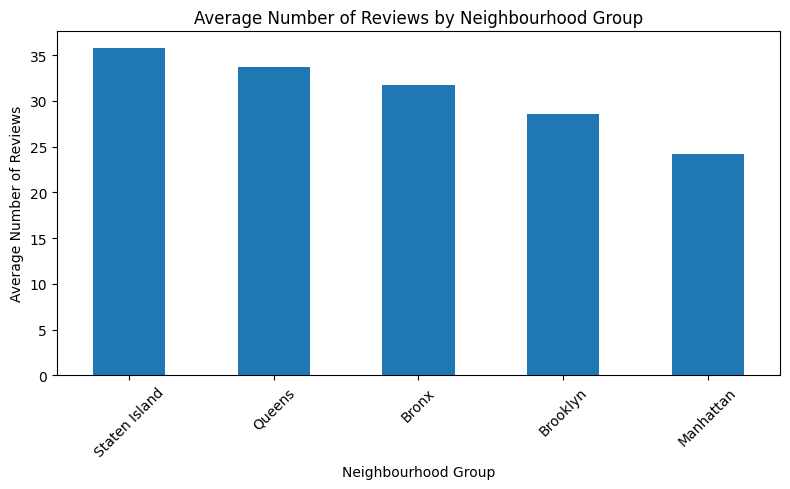

In [158]:
import matplotlib.pyplot as plt

reviews_neighbourhood = (
    df.groupby('neighbourhood group')['number of reviews']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
reviews_neighbourhood.plot(kind='bar')

plt.title('Average Number of Reviews by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Number of Reviews')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [159]:
# Calculate average price by neighbourhood
avg_price_neighbourhood = (
    df.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
)

# Display top 15 neighbourhoods
print(avg_price_neighbourhood.head(15))

neighbourhood
New Dorp                  1045.000000
Chelsea, Staten Island    1042.000000
Fort Wadsworth            1024.000000
Little Neck                817.750000
Jamaica Hills              812.904762
Shore Acres                805.142857
Arden Heights              804.888889
Midland Beach              796.176471
Mill Basin                 775.142857
Riverdale                  768.736842
East Morrisania            764.666667
Morris Heights             742.891304
Pelham Bay                 741.930233
North Riverdale            733.629630
Graniteville               732.571429
Name: price, dtype: float64


In [160]:
avg_rating_group = (
    df.groupby('neighbourhood group')['review rate number']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_rating_group)

neighbourhood group
Staten Island    3.40
Bronx            3.33
Queens           3.33
Manhattan        3.28
Brooklyn         3.26
Name: review rate number, dtype: float64


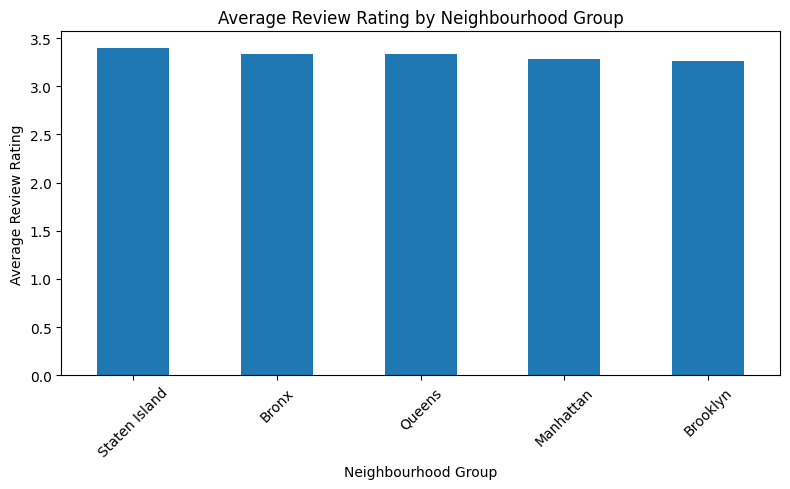

In [161]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

avg_rating_group.plot(kind='bar')

plt.title('Average Review Rating by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Review Rating')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [162]:
avg_min_nights_group = (
    df.groupby('neighbourhood group')['minimum nights']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_min_nights_group)

neighbourhood group
Manhattan        9.42
Brooklyn         6.82
Queens           6.32
Staten Island    5.93
Bronx            5.57
Name: minimum nights, dtype: float64


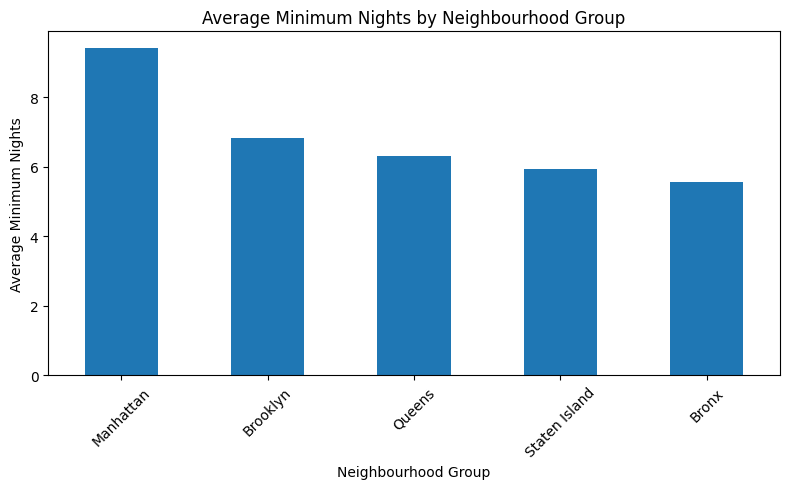

In [163]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

avg_min_nights_group.plot(kind='bar')

plt.title('Average Minimum Nights by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Minimum Nights')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [164]:
avg_price_room_neighbourhood = (
    df.groupby(['neighbourhood group', 'room type'])['price']
    .mean()
    .round(2)
    .unstack()
)

print(avg_price_room_neighbourhood)

room type            Entire home/apt  Hotel room  Private room  Shared room
neighbourhood group                                                        
Bronx                         620.05         NaN        634.42       605.74
Brooklyn                      627.08      711.71        625.57       634.17
Manhattan                     623.36      681.87        620.60       633.56
Queens                        627.00      433.25        631.84       645.21
Staten Island                 642.15         NaN        602.29       715.60


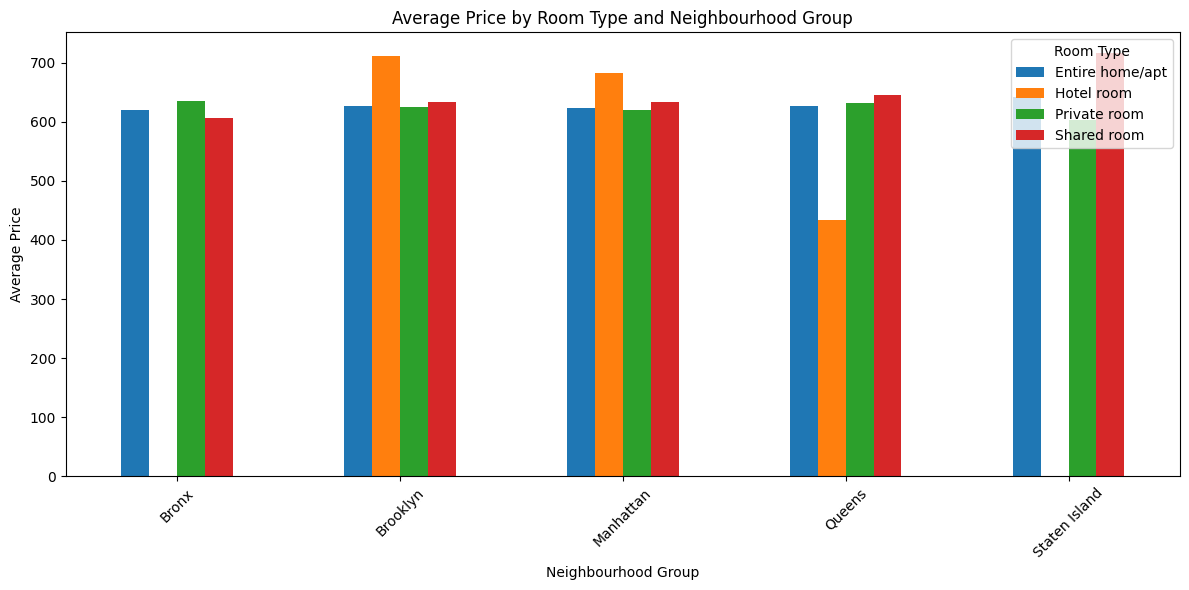

In [165]:
import matplotlib.pyplot as plt

avg_price_room_neighbourhood.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Price by Room Type and Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=45)
plt.legend(title='Room Type')

plt.tight_layout()
plt.show()

In [166]:
avg_price_cancellation = (
    df.groupby('cancellation_policy')['price']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_price_cancellation)

cancellation_policy
flexible    626.22
moderate    625.25
strict      624.59
Name: price, dtype: float64


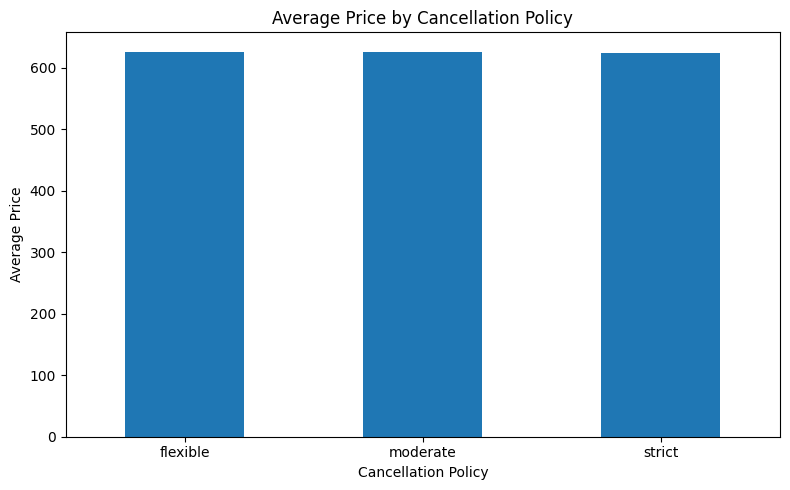

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

avg_price_cancellation.plot(kind='bar')

plt.title('Average Price by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Average Price')

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [168]:
instant_booking = df['instant_bookable'].value_counts()

print(instant_booking)

instant_bookable
False    51291
True     50767
Name: count, dtype: int64


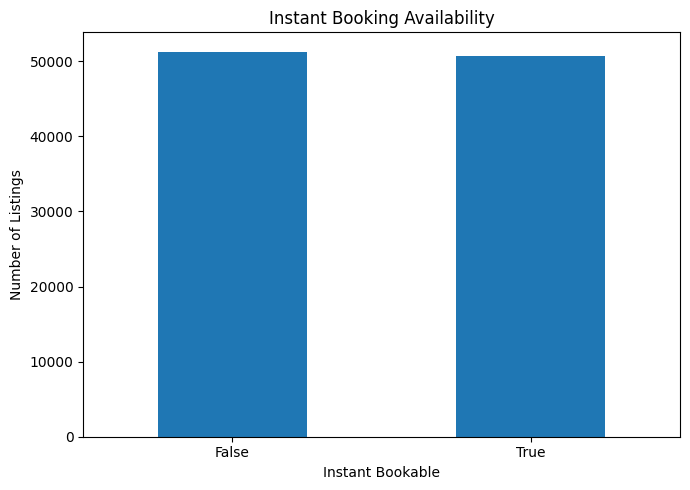

In [169]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

instant_booking.plot(kind='bar')

plt.title('Instant Booking Availability')
plt.xlabel('Instant Bookable')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [170]:
cancellation_instant = pd.crosstab(
    df['cancellation_policy'],
    df['instant_bookable']
)

print(cancellation_instant)

instant_bookable     False  True 
cancellation_policy              
flexible             16844  17047
moderate             17361  16877
strict               17086  16843


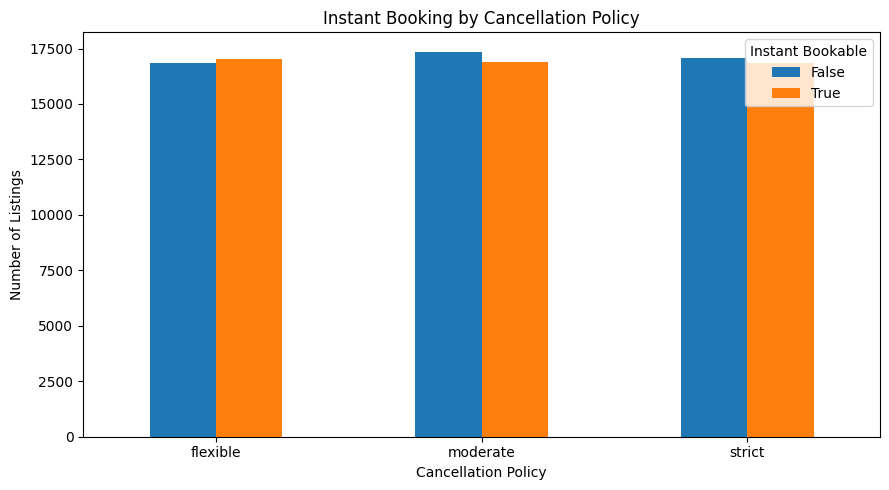

In [171]:
import matplotlib.pyplot as plt

cancellation_instant.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Instant Booking by Cancellation Policy')
plt.xlabel('Cancellation Policy')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.legend(title='Instant Bookable')

plt.tight_layout()
plt.show()

In [172]:
avg_price_instant = (
    df.groupby('instant_bookable')['price']
    .mean()
    .round(2)
)

print(avg_price_instant)

instant_bookable
False    625.19
True     625.51
Name: price, dtype: float64


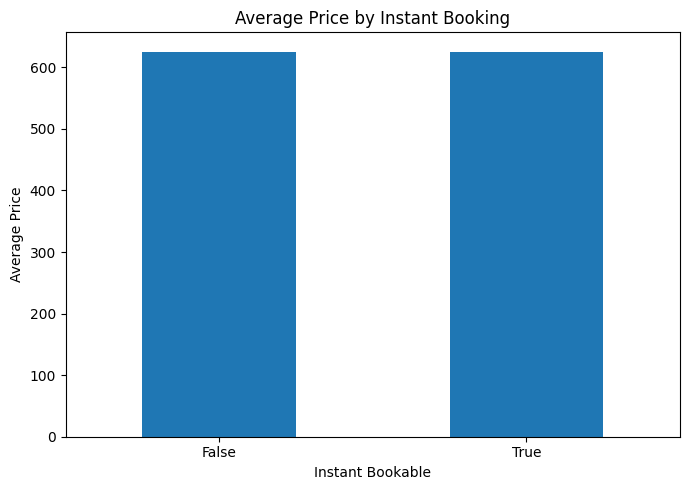

In [173]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

avg_price_instant.plot(kind='bar')

plt.title('Average Price by Instant Booking')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [174]:
avg_rating_instant = (
    df.groupby('instant_bookable')['review rate number']
    .mean()
    .round(2)
)

print(avg_rating_instant)

instant_bookable
False    3.27
True     3.28
Name: review rate number, dtype: float64


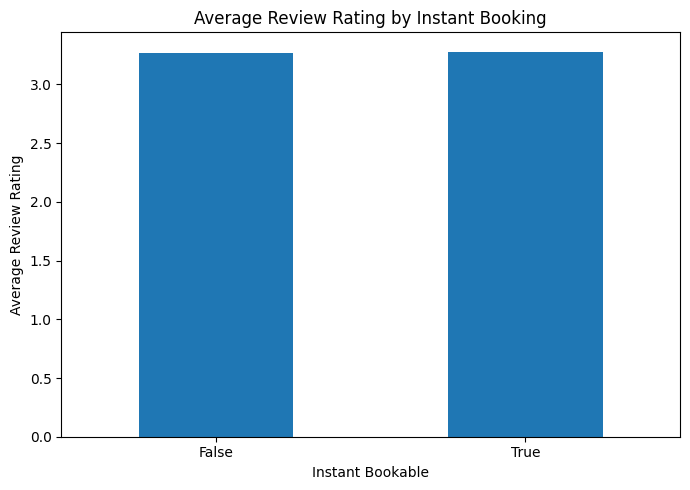

In [175]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

avg_rating_instant.plot(kind='bar')

plt.title('Average Review Rating by Instant Booking')
plt.xlabel('Instant Bookable')
plt.ylabel('Average Review Rating')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [176]:
avg_availability_min_nights = (
    df.groupby('minimum nights')['availability 365']
    .mean()
    .round(2)
)

print(avg_availability_min_nights.head(20))

minimum nights
1.0     148.54
2.0     129.72
3.0     125.06
4.0     112.99
5.0     118.77
6.0     109.32
7.0     120.36
8.0      90.44
9.0      92.15
10.0    103.99
11.0    104.70
12.0     97.73
13.0    103.03
14.0    129.61
15.0    111.43
16.0     94.23
17.0     75.88
18.0    115.44
19.0    114.35
20.0    115.95
Name: availability 365, dtype: float64


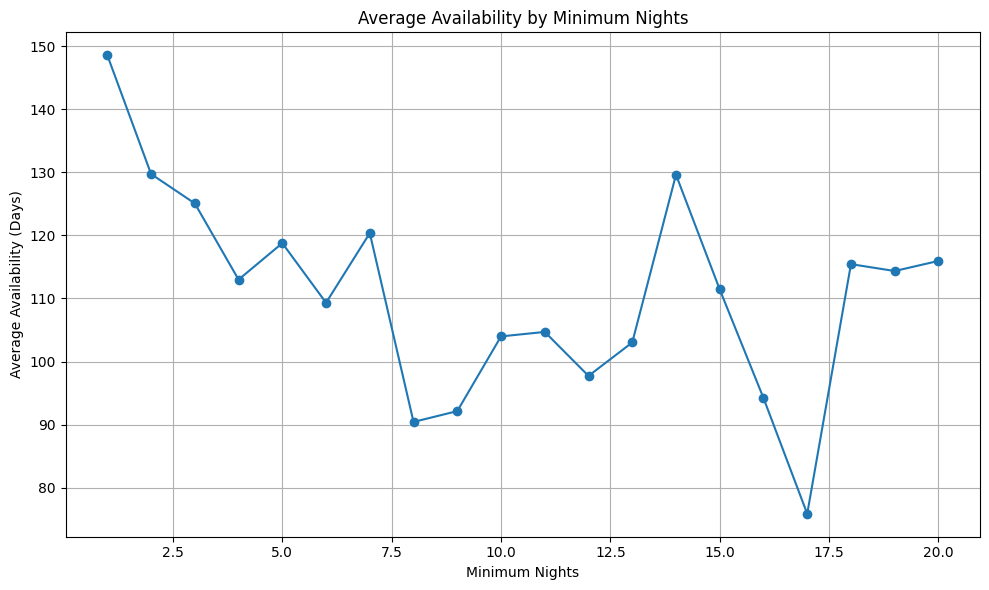

In [177]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

avg_availability_min_nights.head(20).plot(kind='line', marker='o')

plt.title('Average Availability by Minimum Nights')
plt.xlabel('Minimum Nights')
plt.ylabel('Average Availability (Days)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [178]:
avg_reviews_room = (
    df.groupby('room type')['number of reviews']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_reviews_room)

room type
Hotel room         84.08
Private room       27.79
Entire home/apt    27.39
Shared room        20.31
Name: number of reviews, dtype: float64


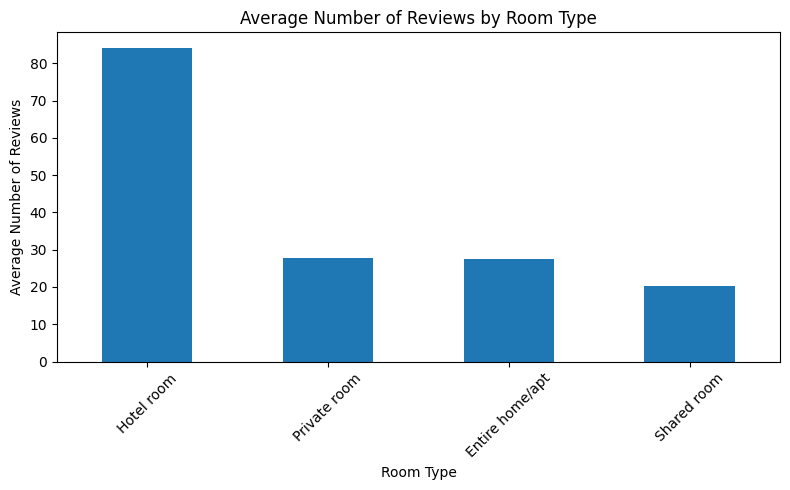

In [179]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

avg_reviews_room.plot(kind='bar')

plt.title('Average Number of Reviews by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Average Number of Reviews')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [180]:
top_hosts = (
    df.groupby('host id')
    .size()
    .sort_values(ascending=False)
    .head(10)
)

print(top_hosts)

host id
29531702698    2
65765635975    1
65765267302    1
65764671629    1
65764610014    1
65761971530    1
65761223145    1
65760166410    1
65760031769    1
65759025233    1
dtype: int64


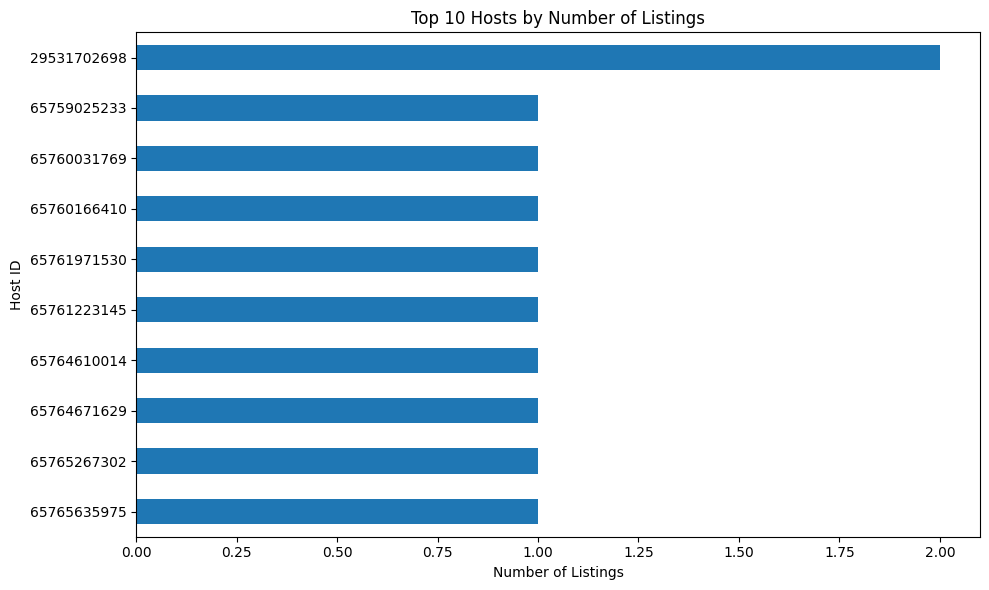

In [181]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_hosts.sort_values().plot(kind='barh')

plt.title('Top 10 Hosts by Number of Listings')
plt.xlabel('Number of Listings')
plt.ylabel('Host ID')

plt.tight_layout()
plt.show()

In [182]:
avg_booking_value_room = (
    df.groupby('room type')['estimated_booking_value']
    .mean()
    .round(2)
    .sort_values(ascending=False)
)

print(avg_booking_value_room)

room type
Entire home/apt    5865.84
Shared room        4053.32
Private room       3738.95
Hotel room         3566.31
Name: estimated_booking_value, dtype: float64


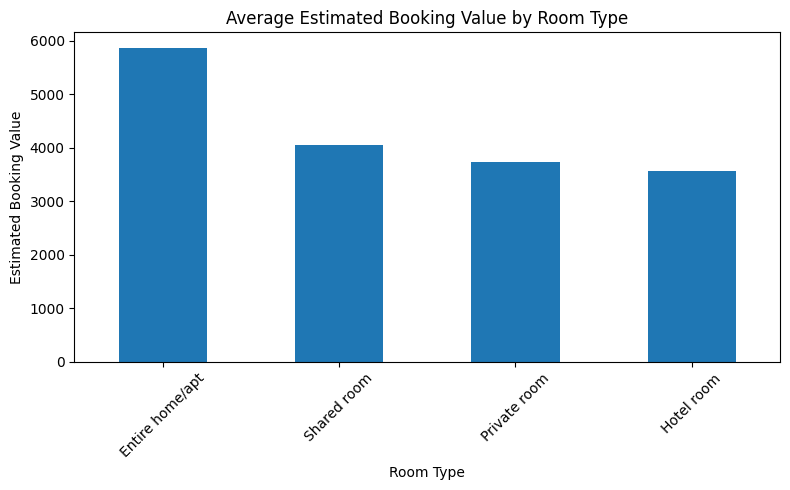

In [183]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

avg_booking_value_room.plot(kind='bar')

plt.title('Average Estimated Booking Value by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Estimated Booking Value')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [184]:
avg_price_verification = (
    df.groupby('host_identity_verified')['price']
    .mean()
    .round(2)
)

print(avg_price_verification)

host_identity_verified
unconfirmed    626.86
verified       623.83
Name: price, dtype: float64


In [185]:
avg_price_verification = (
    df.groupby('host_identity_verified')['price']
    .mean()
    .round(2)
)

print(avg_price_verification)

host_identity_verified
unconfirmed    626.86
verified       623.83
Name: price, dtype: float64


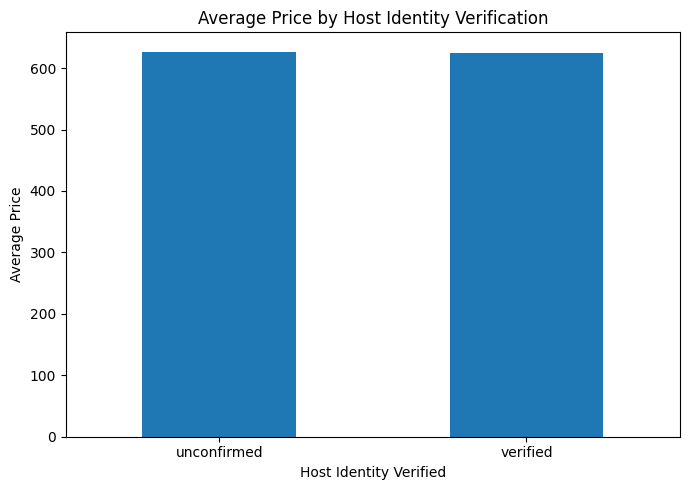

In [186]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

avg_price_verification.plot(kind='bar')

plt.title('Average Price by Host Identity Verification')
plt.xlabel('Host Identity Verified')
plt.ylabel('Average Price')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [187]:
price_policy_verification = (
    df.groupby(['cancellation_policy', 'host_identity_verified'])['price']
    .mean()
    .round(2)
    .unstack()
)

print(price_policy_verification)

host_identity_verified  unconfirmed  verified
cancellation_policy                          
flexible                     627.17    625.27
moderate                     627.25    623.21
strict                       626.15    623.01


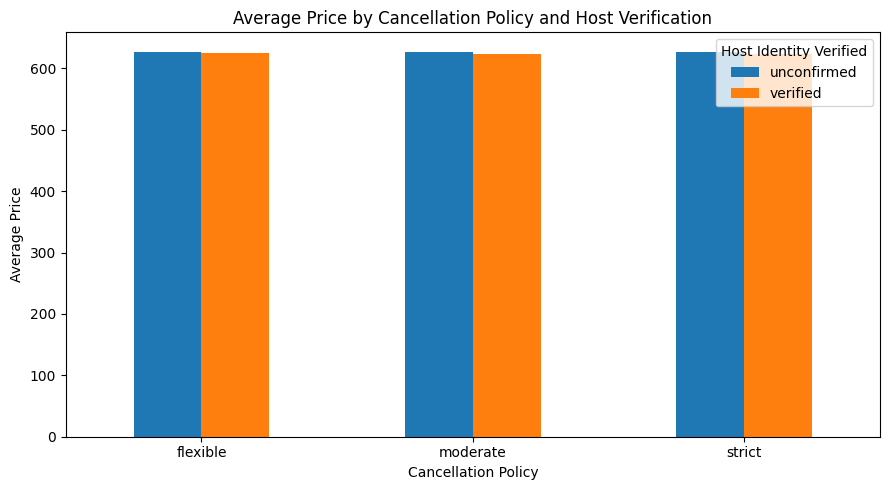

In [188]:
import matplotlib.pyplot as plt

price_policy_verification.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Average Price by Cancellation Policy and Host Verification')
plt.xlabel('Cancellation Policy')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.legend(title='Host Identity Verified')

plt.tight_layout()
plt.show()

In [189]:
print("========== AIRBNB PROJECT SUMMARY ==========")

print("Total Listings:", len(df))
print("Average Price:", round(df['price'].mean(), 2))
print("Median Price:", round(df['price'].median(), 2))
print("Average Reviews:", round(df['number of reviews'].mean(), 2))
print("Average Availability:", round(df['availability 365'].mean(), 2))
print("Average Minimum Nights:", round(df['minimum nights'].mean(), 2))

print("\nMost Common Room Type:")
print(df['room type'].mode()[0])

print("\nMost Common Neighbourhood Group:")
print(df['neighbourhood group'].mode()[0])

print("\nMost Common Cancellation Policy:")
print(df['cancellation_policy'].mode()[0])

print("\nInstant Bookable Listings:")
print(df['instant_bookable'].value_counts())

========== AIRBNB PROJECT SUMMARY ==========
Total Listings: 102058
Average Price: 625.35
Median Price: 624.0
Average Reviews: 27.48
Average Availability: 140.01
Average Minimum Nights: 7.82

Most Common Room Type:
Entire home/apt

Most Common Neighbourhood Group:
Manhattan

Most Common Cancellation Policy:
moderate

Instant Bookable Listings:
instant_bookable
False    51291
True     50767
Name: count, dtype: int64


In [191]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
